In [1]:
# Cell 0b — Mount Google Drive and extract dataset
# ── Step 1: Run this on your LOCAL machine (Terminal) to zip the dataset ──
# cd /Users/BAEK/Code/gaitkeeper
# zip -r data_processed.zip data_processed/
#
# ── Step 2: Upload data_processed.zip to your Google Drive (MyDrive/Colab/) ──
#
# ── Step 3: Run cells in order: this cell → Cell 1 (installs) → Cell 2 (imports) → Cell 3+ ──

from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Colab/data_processed.zip'

if not os.path.exists('/content/data_processed'):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print("Done.")
else:
    print("Dataset already extracted.")

import glob
videos = glob.glob('/content/data_processed/**/*.mp4', recursive=True)
print(f"Found {len(videos)} videos:")

Mounted at /content/drive
Extracting dataset...
Done.
Found 34 videos:


In [2]:
# Cell 1 — Installs
!pip install ultralytics kornia --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 124.3 MB/s eta 0:00:00


In [3]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H       = 200      # patch height in pixels
PATCH_W       = 150      # patch width in pixels
PATCH_SCALE   = 0.3      # fraction of detected person width used for patch
SHIRT_TOP     = 0.20     # top of shirt region as fraction of person bbox height
SHIRT_BOT     = 0.55     # bottom of shirt region as fraction of person bbox height
EPSILON       = 0.15     # max pixel delta from initialization (0–1 range)
LR            = 0.01     # Adam learning rate
NUM_STEPS     = 500      # total training steps
EOT_N         = 8        # EoT transforms per step
TOP_K         = 50       # top anchors to target in confidence loss
CONF_LOSS_W   = 0.6      # weight for Top-K confidence loss
SEG_LOSS_W    = 0.4      # weight for mask suppression loss

# ── Dataset ────────────────────────────────────────────
# Set to True to load pre-built samples from Drive (fast).
# Set to False to re-extract frames from videos (slow, needed if videos change).
USE_CACHED_SAMPLES = True

# ── Input ──────────────────────────────────────────────
DRIVE_DIR        = "/content/drive/MyDrive/Colab"
IMAGE_PATH       = f"{DRIVE_DIR}/person.jpg"
VIDEO_DIR        = "/content/data_processed"
FRAMES_PER_VIDEO = 10
SAMPLES_PATH     = f"{DRIVE_DIR}/training_samples.pkl"

# ── Model ──────────────────────────────────────────────
YOLO_MODEL    = "yolov8n-seg"
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f"Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}")

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [6]:
# Cell 5 — Raw forward pass helper
def yolo_raw_forward(img_tensor):
    out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [7]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Detects the highest-confidence person and returns:
        shirt_box_img: (x1, y1, x2, y2) in 640x640 image coordinates
        shirt_box_mask: (x1, y1, x2, y2) in 160x160 mask coordinates
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    # Find highest-confidence person detection (class 0)
    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    box = boxes.xyxy[person_mask][best_idx].cpu().numpy()  # [x1, y1, x2, y2]

    x1, y1, x2, y2 = box
    h = y2 - y1
    w = x2 - x1
    cx = (x1 + x2) / 2
    # Shirt region: centered horizontal band scaled by PATCH_SCALE
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    # Scale to mask resolution (160x160 = 640/4)
    scale = 160 / 640
    mx1, my1 = int(sx1 * scale), int(sy1 * scale)
    mx2, my2 = int(sx2 * scale), int(sy2 * scale)

    # Clamp to valid range
    mx1, my1 = max(0, mx1), max(0, my1)
    mx2, my2 = min(159, mx2), min(159, my2)

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box):
    """
    img_tensor: [1, 3, 640, 640] float32
    patch: [1, 3, PATCH_H, PATCH_W] float32, differentiable
    shirt_box: (x1, y1, x2, y2) in image coords
    Returns: patched image tensor [1, 3, 640, 640]
    """
    x1, y1, x2, y2 = int(shirt_box[0]), int(shirt_box[1]), int(shirt_box[2]), int(shirt_box[3])
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return img_tensor

    # Resize patch to shirt region dimensions
    patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)

    # Clone and paste (preserve gradient graph through patch_resized)
    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = patch_resized
    return patched

In [8]:
# Cell 7 — Loss functions
def topk_conf_loss(raw, k=TOP_K, patch_box_img=None):
    """
    If patch_box_img is given, target anchors spatially overlapping the patch region.
    Otherwise fall back to global top-K (less effective when patch is small).
    YOLOv8 anchor grid: 80x80 (stride 8) + 40x40 (stride 16) + 20x20 (stride 32) = 8400 total.
    """
    preds = raw['preds']                          # [1, 116, 8400]
    class_logits = preds[0, 4:84, :]             # [80, 8400]
    max_logits = class_logits.max(dim=0)[0]      # [8400]
    conf = torch.sigmoid(max_logits)             # [8400]

    if patch_box_img is not None:
        px1, py1, px2, py2 = patch_box_img
        # Build anchor center coords for YOLOv8 on 640x640
        strides = [8, 16, 32]
        grids = [80, 40, 20]
        centers_x, centers_y = [], []
        for stride, g in zip(strides, grids):
            xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
            ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
            yy, xx = torch.meshgrid(ys, xs, indexing='ij')
            centers_x.append(xx.reshape(-1))
            centers_y.append(yy.reshape(-1))
        cx = torch.cat(centers_x)  # [8400]
        cy = torch.cat(centers_y)  # [8400]

        in_patch = (cx >= px1) & (cx <= px2) & (cy >= py1) & (cy <= py2)
        if in_patch.sum() > 0:
            return conf[in_patch].mean()
        # fallback if patch is tiny and no anchors land inside
        # use anchors near patch center
        patch_cx = (px1 + px2) / 2
        patch_cy = (py1 + py2) / 2
        dist = (cx - patch_cx).pow(2) + (cy - patch_cy).pow(2)
        nearest = dist.topk(k, largest=False).indices
        return conf[nearest].mean()

    # global top-K fallback
    top_k_vals = torch.topk(conf, k=k).values
    return top_k_vals.mean()

In [9]:
# Cell 8 — Mask suppression loss and combined loss
def mask_suppression_loss(raw, patch_box_mask):
    """
    Assemble the segmentation mask for the highest-confidence detection,
    then minimize its probability in the patch region.
    Directly degrades silhouette quality where the patch sits.
    """
    preds = raw['preds']                              # [1, 116, 8400]
    proto = raw['proto']                              # [1, 32, 160, 160]

    class_logits = preds[0, 4:84, :]
    conf = torch.sigmoid(class_logits.max(0)[0])      # [8400]
    best = conf.argmax()

    # Skip if no confident detection — return zero loss with grad
    if conf[best].item() < 0.1:
        return preds[0, 84:, 0].sum() * 0.0

    mask_coeff = preds[0, 84:, best]                  # [32]
    proto_flat = proto[0].reshape(32, -1)             # [32, 160*160]
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob = torch.sigmoid(mask_logits)            # [160, 160]

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]

    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0

    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    """Weighted sum of spatially-targeted confidence loss and mask suppression loss."""
    conf_loss = topk_conf_loss(raw, patch_box_img=patch_box_img)
    seg_loss  = mask_suppression_loss(raw, patch_box_mask)
    return CONF_LOSS_W * conf_loss + SEG_LOSS_W * seg_loss

In [10]:
# Cell 9 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """
    patch: [1, 3, PATCH_H, PATCH_W] float32, grad-enabled
    Returns: transformed patch, same shape, gradient preserved
    All transforms use kornia or raw torch — no PIL/numpy (which break autograd).
    """
    p = patch  # keep reference for conditional applications

    # Brightness: multiply by scalar in [0.6, 1.4]
    if random.random() < 0.5:
        factor = random.uniform(0.6, 1.4)
        p = (p * factor).clamp(0, 1)

    # Hue/Saturation jitter ±10%
    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    # Rotation ±15°
    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    # Perspective warp (slight fabric curvature)
    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    # Motion blur
    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        blur_angle = random.uniform(0, 360)
        p = kornia.filters.motion_blur(p, kernel_size=ksize, angle=blur_angle, direction=0.0)

    # Gaussian noise (pure torch, stays differentiable)
    if random.random() < 0.5:
        sigma = random.uniform(0, 10) / 255.0
        p = p + torch.randn_like(p) * sigma

    return p.clamp(0, 1)

In [11]:
# Cell 10 — Baseline: measure confidence before training
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load {IMAGE_PATH} — check Drive upload")

img_tensor = img_to_tensor(img)

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_tensor)

baseline_conf = topk_conf_loss(raw_baseline).item()
print(f"Baseline Top-{TOP_K} mean confidence: {baseline_conf:.4f}")

Baseline Top-50 mean confidence: 0.5414


In [12]:
# Cell 11 — Initialize patch
torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f"Patch initialized: shape {list(patch.shape)}, range [{patch.min():.2f}, {patch.max():.2f}]")

Patch initialized: shape [1, 3, 200, 150], range [0.40, 0.60]


In [13]:
# Cell 12 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f"Loaded {len(training_samples)} samples from {SAMPLES_PATH}")
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f"{VIDEO_DIR}/**/*.mp4", recursive=True)
    print(f"Found {len(video_paths)} videos. Extracting frames...")

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                training_samples.append((frame, b_img, b_mask))
                valid += 1
        print(f"  {Path(vp).name}: {valid}/{len(frames)} frames detected")

    # Save for next time
    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f"\nSaved {len(training_samples)} samples to {SAMPLES_PATH}")

print(f"Total training samples: {len(training_samples)}")

Loaded 280 samples from /content/drive/MyDrive/Colab/training_samples.pkl
Total training samples: 280


In [14]:
# Cell 13 — Training loop
if not training_samples:
    raise RuntimeError("No valid training samples — check Cell 12")
print(f"Training on {len(training_samples)} samples.")

loss_history = []

for step in range(NUM_STEPS):
    optimizer.zero_grad()
    step_loss = 0.0

    for _ in range(EOT_N):
        img, box_img, box_mask = random.choice(training_samples)
        img_tensor = img_to_tensor(img)

        aug_patch = apply_eot_transforms(patch)
        patched_img = paste_patch(img_tensor, aug_patch, box_img)
        raw = yolo_raw_forward(patched_img)
        loss = combined_loss(raw, box_img, box_mask) / EOT_N
        loss.backward()
        step_loss += loss.item()

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    mean_loss = step_loss / EOT_N
    loss_history.append(mean_loss)

    if step % 10 == 0:
        print(f"Step {step:3d}/{NUM_STEPS} | loss {mean_loss:.4f}")

print("Training complete.")

Training on 280 samples.
Step   0/500 | loss 0.0601
Step  10/500 | loss 0.0555
Step  20/500 | loss 0.0618
Step  30/500 | loss 0.0529
Step  40/500 | loss 0.0501
Step  50/500 | loss 0.0443
Step  60/500 | loss 0.0601
Step  70/500 | loss 0.0564
Step  80/500 | loss 0.0548
Step  90/500 | loss 0.0538
Step 100/500 | loss 0.0549
Step 110/500 | loss 0.0488
Step 120/500 | loss 0.0585
Step 130/500 | loss 0.0604
Step 140/500 | loss 0.0659
Step 150/500 | loss 0.0534
Step 160/500 | loss 0.0579
Step 170/500 | loss 0.0478
Step 180/500 | loss 0.0562
Step 190/500 | loss 0.0550
Step 200/500 | loss 0.0602
Step 210/500 | loss 0.0477
Step 220/500 | loss 0.0551
Step 230/500 | loss 0.0542
Step 240/500 | loss 0.0486
Step 250/500 | loss 0.0645
Step 260/500 | loss 0.0581
Step 270/500 | loss 0.0469
Step 280/500 | loss 0.0551
Step 290/500 | loss 0.0528
Step 300/500 | loss 0.0565
Step 310/500 | loss 0.0567
Step 320/500 | loss 0.0551
Step 330/500 | loss 0.0459
Step 340/500 | loss 0.0447
Step 350/500 | loss 0.0573
Ste

In [15]:
# Cell 14 — Evaluation metrics
img = cv2.imread(IMAGE_PATH)
img_tensor = img_to_tensor(img)
box_img, box_mask = detect_shirt_region(img)

with torch.no_grad():
    raw_clean = yolo_raw_forward(img_tensor)
    clean_conf = topk_conf_loss(raw_clean, patch_box_img=box_img).item()
    clean_mask_prob = mask_suppression_loss(raw_clean, box_mask).item()

    patch_applied = paste_patch(img_tensor, patch, box_img)
    raw_patched = yolo_raw_forward(patch_applied)
    patched_conf = topk_conf_loss(raw_patched, patch_box_img=box_img).item()
    patched_mask_prob = mask_suppression_loss(raw_patched, box_mask).item()

conf_drop_pct = (clean_conf - patched_conf) / clean_conf * 100
print("─" * 45)
print(f"{'Metric':<30} {'Clean':>6}  {'Patched':>7}")
print("─" * 45)
print(f"{'Patch-region conf (lower=better)':<30} {clean_conf:>6.4f}  {patched_conf:>7.4f}")
print(f"{'Mask prob in patch region':<30} {clean_mask_prob:>6.4f}  {patched_mask_prob:>7.4f}")
print("─" * 45)
print(f"Confidence drop: {conf_drop_pct:.1f}%")

─────────────────────────────────────────────
Metric                          Clean  Patched
─────────────────────────────────────────────
Patch-region conf (lower=better) 0.5092   0.5118
Mask prob in patch region      0.9989   0.1787
─────────────────────────────────────────────
Confidence drop: -0.5%


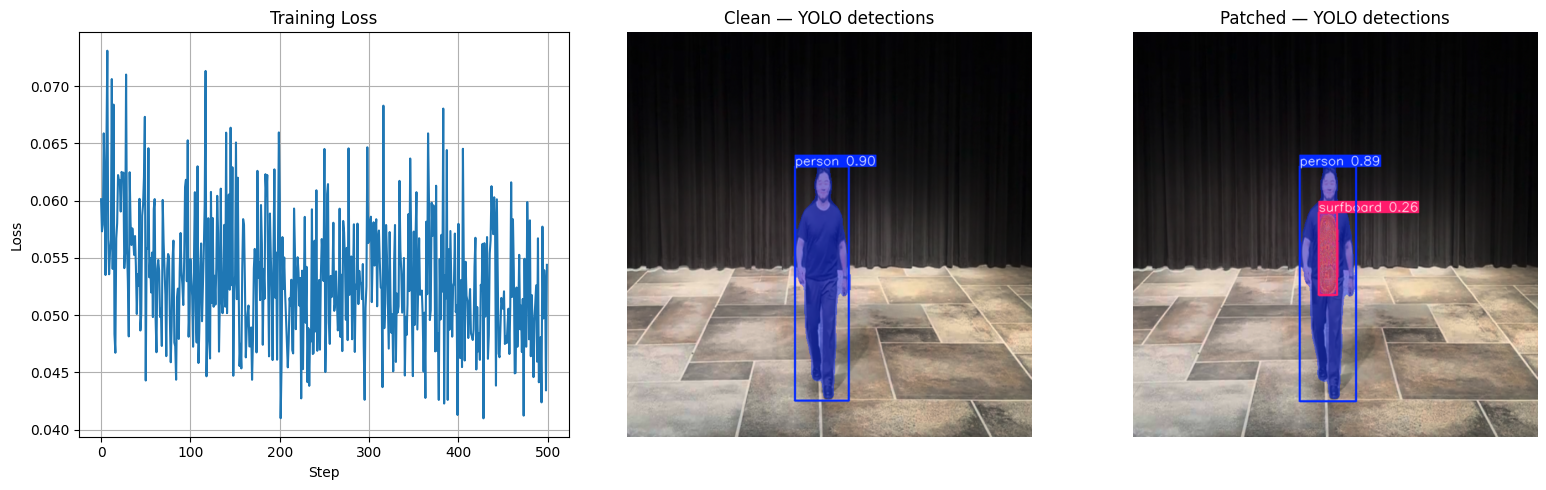

In [16]:
# Cell 15 — Visual evaluation on person.jpg
img = cv2.imread(IMAGE_PATH)
img_640 = cv2.resize(img, (640, 640))
box_img, _ = detect_shirt_region(img)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)
x1, y1, x2, y2 = box_img
patch_resized = cv2.resize(patch_np, (x2 - x1, y2 - y1))
img_patched = img_640.copy()
img_patched[y1:y2, x1:x2] = cv2.cvtColor(patch_resized, cv2.COLOR_RGB2BGR)

results_clean   = yolo(img_640,     verbose=False)
results_patched = yolo(img_patched, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(loss_history)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].imshow(cv2.cvtColor(results_clean[0].plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title("Clean — YOLO detections")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(results_patched[0].plot(), cv2.COLOR_BGR2RGB))
axes[2].set_title("Patched — YOLO detections")
axes[2].axis('off')

plt.tight_layout()
plt.show()